Extended Data Figure 6 — peak-class accessibility (promoters, enhancers, LTR, LINE, SINE, DNA transposons)

6×6 ATAC-seq counts/cell by genomic class, all six TEA-seq samples. Run from this folder. Set `PATH_TO_DATA`.

1. A4 figure
2. Naked panels for PowerPoint
3. PowerPoint assembly


In [1]:
"""A4 Nature layout: ATAC-seq counts / cell by cluster × peak class, all patients.

6 rows (patients) × 6 columns (Promoters, Enhancers, LTR, LINE, SINE,
DNA transposons). Same ANOVA + 95% CI bars as plot_cluster_openness_with_stats.

A4 portrait 210 × 297 mm. Helvetica 5–7 pt, 8 pt bold headers, 0.5 pt lines.
pdf.fonttype = 42.

Set PATH_TO_DATA to the folder that contains the MultiVI objects and
peak-annotation TSVs (see PATIENTS below).
"""

from __future__ import annotations

import json
import os
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import MaxNLocator
from scipy import sparse
from scipy.stats import f as fdist
from scipy.stats import f_oneway

MM = 1 / 25.4
FIG_W = 210 * MM
FIG_H = 297 * MM

FONT = "Helvetica"
mpl.rcParams.update(
    {
        "font.family": "sans-serif",
        "font.sans-serif": [FONT, "Arial", "DejaVu Sans"],
        "font.size": 6,
        "axes.labelsize": 6,
        "axes.titlesize": 8,
        "xtick.labelsize": 5,
        "ytick.labelsize": 5,
        "axes.linewidth": 0.5,
        "xtick.major.width": 0.5,
        "ytick.major.width": 0.5,
        "xtick.major.size": 1.6,
        "ytick.major.size": 1.6,
        "hatch.linewidth": 0.3,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "pdf.use14corefonts": False,
        "axes.unicode_minus": False,
        "savefig.bbox": None,
        "savefig.facecolor": "white",
    }
)

OUT = Path.cwd()

CLASSES = [
    {"key": "promoter", "title": "Promoters"},
    {"key": "enhancer", "title": "Enhancers"},
    {"key": "LTR", "title": "LTR"},
    {"key": "LINE", "title": "LINE"},
    {"key": "SINE", "title": "SINE"},
    {"key": "DNA", "title": "DNA transposons"},
]

# Relative to PATH_TO_DATA. Objects are the Cluster_Final MultiVI files used
# for the LSC-identification peak-class bars (not the later reclustered
# trajectory copies).
PATIENTS = [
    {
        "label": "Patient 1",
        "h5ad": "TALL_Website/Object/PB2/Teaseq_Multi_VI_PB2_Cleaned.h5ad",
        "annot": "New_Analysis/Scenicplus/New_PB2/teapb2_peaks_annotated.tsv",
    },
    {
        "label": "Patient 1′",
        "h5ad": "New_Analysis/Scenicplus/New_BM4/Teaseq_Multi_VI_BM4_Cleaned.h5ad",
        "annot": "New_Analysis/Scenicplus/New_BM4/teabm4_peaks_annotated.tsv",
    },
    {
        "label": "Patient 2",
        "h5ad": "TALL_Website/Object/PB3/Teaseq_Multi_VI_PB3_Cleaned.h5ad",
        "annot": "New_Analysis/Scenicplus/New_PB3/teapb3_peaks_annotated.tsv",
    },
    {
        "label": "Patient 3",
        "h5ad": "New_Analysis/Scenicplus/New_BM5/Teaseq_Multi_VI_BM5_Cleaned.h5ad",
        "annot": "New_Analysis/Scenicplus/New_BM5/teabm5_peaks_annotated.tsv",
    },
    {
        "label": "Patient 4",
        "h5ad": "New_Analysis/Scenicplus/New_BM1/Teaseq_Multi_VI_BM1_Cleaned.h5ad",
        "annot": "New_Analysis/Scenicplus/New_BM1/teabm1_peaks_annotated.tsv",
    },
    {
        "label": "Patient 5",
        "h5ad": "New_Analysis/Scenicplus/New_BM3/Teaseq_Multi_VI_BM3_Cleaned.h5ad",
        "annot": "New_Analysis/Scenicplus/New_BM3/teabm3_peaks_annotated.tsv",
    },
]


def data_root() -> Path:
    return Path(os.environ.get("PATH_TO_DATA", "PATH_TO_DATA"))


def anova_p_text(df, cats, metric="n_peaks"):
    groups = [
        df.loc[df["Cluster_Final"] == c, metric].dropna().to_numpy() for c in cats
    ]
    groups = [g for g in groups if len(g) >= 2]
    if len(groups) < 2:
        return "p = NA", "P = NA"
    F, _ = f_oneway(*groups)
    dfn = len(groups) - 1
    dfd = sum(len(g) for g in groups) - len(groups)
    logp = fdist.logsf(F, dfn, dfd)
    p = float(np.exp(logp))
    if p < 1e-300 or not np.isfinite(p):
        return r"$P$ < 1×10$^{-300}$", "P < 1×10⁻³⁰⁰"
    exp = int(np.floor(np.log10(p)))
    mant = p / (10**exp)
    latex = rf"$P$ = {mant:.1f}×10$^{{{exp}}}$"
    sup = str(exp).translate(str.maketrans("0123456789+-", "⁰¹²³⁴⁵⁶⁷⁸⁹⁺⁻"))
    plain = f"P = {mant:.1f}×10{sup}"
    return latex, plain


def cluster_colors(adata):
    cats = list(adata.obs["Cluster_Final"].astype("category").cat.categories)
    cats = [str(c) for c in cats]
    raw = list(adata.uns.get("Cluster_Final_colors", []))
    if len(raw) < len(cats):
        cmap = plt.get_cmap("tab10")
        raw = [cmap(i) for i in range(len(cats))]
    return cats, [raw[i] for i in range(len(cats))]


def annotate_peaks(adata, annot_path: Path):
    annot = pd.read_csv(annot_path, sep="\t")
    annot_collapsed = (
        annot.groupby(["seqnames", "start", "end"])["regulatory_element_type"]
        .apply(
            lambda s: ";".join(sorted(set(s.dropna().astype(str))))
            if s.dropna().size
            else np.nan
        )
        .reset_index()
        .rename(columns={"seqnames": "chr", "regulatory_element_type": "RE"})
    )
    repclass_collapsed = (
        annot.groupby(["seqnames", "start", "end"])["repClass"]
        .apply(
            lambda s: ";".join(sorted(set(s.dropna().astype(str))))
            if s.dropna().size
            else np.nan
        )
        .reset_index()
        .rename(columns={"seqnames": "chr", "repClass": "repClass_collapsed"})
    )
    var_df = adata.var.reset_index()
    var_df["start"] = pd.to_numeric(var_df["start"], errors="coerce")
    var_df["end"] = pd.to_numeric(var_df["end"], errors="coerce")
    var_merged = var_df.merge(annot_collapsed, on=["chr", "start", "end"], how="left")
    var_merged = var_merged.merge(
        repclass_collapsed, on=["chr", "start", "end"], how="left"
    )
    adata.var["RE"] = var_merged["RE"].values
    for cls in ["LTR", "DNA", "LINE", "SINE"]:
        adata.var[cls] = (
            var_merged["repClass_collapsed"].fillna("").str.contains(cls).to_numpy()
        )
    n_peak = int((adata.var["feature_types"] == "Peaks").sum()) if "feature_types" in adata.var else adata.n_vars
    n_ann = int(adata.var["RE"].notna().sum())
    print(f"  annotated {n_ann}/{n_peak} peaks with RE")
    return adata


def peak_mask(adata, key: str):
    is_peak = (
        adata.var["feature_types"].eq("Peaks")
        if "feature_types" in adata.var
        else pd.Series(True, index=adata.var_names)
    )
    if key == "promoter":
        return is_peak & adata.var["RE"].isin(["Promoter", "Promoter/Enhancer"])
    if key == "enhancer":
        return is_peak & adata.var["RE"].eq("Enhancer")
    return is_peak & adata.var[key].eq(True)


def count_peaks(adata, mask):
    idx = np.where(mask.to_numpy())[0]
    if len(idx) == 0:
        return np.zeros(adata.n_obs, dtype=float)
    X = adata.X[:, idx]
    if sparse.issparse(X):
        return np.asarray(X.sum(axis=1)).ravel().astype(float)
    return np.asarray(X.sum(axis=1)).ravel().astype(float)


def panel_stats(adata, mask, cats, colors):
    n_peaks = count_peaks(adata, mask)
    df = pd.DataFrame(
        {
            "Cluster_Final": adata.obs["Cluster_Final"].astype(str).to_numpy(),
            "n_peaks": n_peaks,
        }
    )
    df = df.dropna()
    means = df.groupby("Cluster_Final", observed=True)["n_peaks"].mean().reindex(cats)
    sem = df.groupby("Cluster_Final", observed=True)["n_peaks"].sem().reindex(cats)
    ci = 1.96 * sem
    ptxt, ptxt_plain = anova_p_text(df, cats)
    max_i = int(np.nanargmax(means.to_numpy())) if means.notna().any() else 0
    return {
        "cats": cats,
        "colors": colors,
        "means": means.to_numpy(dtype=float),
        "ci": ci.fillna(0).to_numpy(dtype=float),
        "ptxt": ptxt,
        "ptxt_plain": ptxt_plain,
        "max_i": max_i,
        "n_peaks_class": int(mask.sum()),
    }


def plot_bar(ax, stats, ylabel=False, xlabel=False):
    cats = stats["cats"]
    x = np.arange(len(cats))
    bars = ax.bar(
        x,
        stats["means"],
        yerr=stats["ci"],
        color=stats["colors"],
        edgecolor="black",
        linewidth=0.35,
        error_kw={"elinewidth": 0.45, "capsize": 1.1, "capthick": 0.45},
        zorder=2,
        width=0.82,
    )
    bars[stats["max_i"]].set_hatch("//")
    bars[stats["max_i"]].set_linewidth(0.55)
    ax.set_xticks(x)
    ax.set_xticklabels(cats)
    if xlabel:
        ax.set_xlabel("Cluster", labelpad=1)
    else:
        ax.set_xlabel("")
    if ylabel:
        ax.set_ylabel("ATAC-seq counts / cell", labelpad=2)
    else:
        ax.set_ylabel("")
    ax.yaxis.set_major_locator(MaxNLocator(nbins=3, min_n_ticks=2, integer=False))
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_axisbelow(True)
    ax.yaxis.grid(True, linewidth=0.25, color="0.88")
    ymax = np.nanmax(stats["means"] + stats["ci"])
    ax.set_ylim(0, ymax * 1.12 if np.isfinite(ymax) and ymax > 0 else 1)
    ax.tick_params(axis="both", pad=1.0)


def _rgb(color):
    r, g, b, _ = mpl.colors.to_rgba(color)
    from pptx.dml.color import RGBColor

    return RGBColor(int(r * 255), int(g * 255), int(b * 255))


def _set_run(run, text, size, bold=False, name="Helvetica"):
    from pptx.dml.color import RGBColor
    from pptx.util import Pt

    run.text = text
    run.font.size = Pt(size)
    run.font.bold = bold
    run.font.name = name
    run.font.color.rgb = RGBColor(0, 0, 0)


def add_textbox(slide, x_mm, y_mm, w_mm, h_mm, text, size=6, bold=False, align="center", rotation=0):
    from pptx.enum.text import PP_ALIGN
    from pptx.util import Mm, Pt

    box = slide.shapes.add_textbox(Mm(x_mm), Mm(y_mm), Mm(w_mm), Mm(h_mm))
    if rotation:
        box.rotation = rotation
    tf = box.text_frame
    tf.word_wrap = True
    tf.auto_size = None
    for m in ("margin_left", "margin_right", "margin_top", "margin_bottom"):
        setattr(tf, m, Pt(0))
    try:
        tf._txBody.bodyPr.set("anchor", "ctr")
    except Exception:
        pass
    p = tf.paragraphs[0]
    p.alignment = {
        "center": PP_ALIGN.CENTER,
        "left": PP_ALIGN.LEFT,
        "right": PP_ALIGN.RIGHT,
    }[align]
    run = p.add_run()
    _set_run(run, text, size, bold=bold)
    return box


def add_line(slide, x1, y1, x2, y2, weight=0.5, color=None):
    from pptx.dml.color import RGBColor
    from pptx.enum.shapes import MSO_CONNECTOR
    from pptx.util import Mm, Pt

    if color is None:
        color = RGBColor(0, 0, 0)
    conn = slide.shapes.add_connector(
        MSO_CONNECTOR.STRAIGHT, Mm(x1), Mm(y1), Mm(x2), Mm(y2)
    )
    conn.line.color.rgb = color
    conn.line.width = Pt(weight)
    return conn


def write_pptx(all_stats, path: Path):
    from pptx import Presentation
    from pptx.dml.color import RGBColor
    from pptx.enum.dml import MSO_PATTERN_TYPE
    from pptx.enum.shapes import MSO_SHAPE
    from pptx.util import Mm, Pt

    prs = Presentation()
    prs.slide_width = Mm(210)
    prs.slide_height = Mm(297)
    slide = prs.slides.add_slide(prs.slide_layouts[6])

    margin_l, margin_r, margin_t, margin_b = 18.0, 4.0, 11.0, 8.0
    gap_x, gap_y = 3.0, 5.0
    n = 6
    cell_w = (210 - margin_l - margin_r - gap_x * (n - 1)) / n
    cell_h = (297 - margin_t - margin_b - gap_y * (n - 1)) / n
    gray = RGBColor(220, 220, 220)

    for c, cls in enumerate(CLASSES):
        x = margin_l + c * (cell_w + gap_x)
        add_textbox(slide, x, 2.0, cell_w, 5.5, cls["title"], size=8, bold=True)

    for r, spec in enumerate(PATIENTS):
        y = margin_t + r * (cell_h + gap_y)
        add_textbox(
            slide,
            1.2,
            y,
            14.5,
            cell_h,
            spec["label"].replace("′", "'"),
            size=8,
            bold=True,
            rotation=270,
        )

        for c, cls in enumerate(CLASSES):
            stats = all_stats[r][cls["key"]]
            x = margin_l + c * (cell_w + gap_x)
            add_textbox(
                slide,
                x,
                y,
                cell_w,
                4.2,
                stats["ptxt_plain"],
                size=5,
                bold=False,
            )

            pad_l = 7.2 if c == 0 else 1.6
            pad_b = 5.8 if r == 5 else 3.6
            plot_x = x + pad_l
            plot_y = y + 4.6
            plot_w = cell_w - pad_l - 0.8
            plot_h = cell_h - 4.6 - pad_b
            ymax = float(np.nanmax(stats["means"] + stats["ci"]))
            ymax = ymax * 1.12 if np.isfinite(ymax) and ymax > 0 else 1.0
            locator = MaxNLocator(nbins=3, min_n_ticks=2)
            ticks = [t for t in locator.tick_values(0, ymax) if 0 <= t <= ymax * 1.001]

            for t in ticks:
                yy = plot_y + plot_h * (1 - t / ymax)
                add_line(slide, plot_x, yy, plot_x + plot_w, yy, weight=0.25, color=gray)
                if c == 0:
                    label = "0" if t == 0 else f"{t:.0f}"
                    add_textbox(
                        slide, x, yy - 1.6, pad_l - 0.3, 3.2, label, size=5, align="right"
                    )

            add_line(slide, plot_x, plot_y, plot_x, plot_y + plot_h, weight=0.5)
            add_line(
                slide, plot_x, plot_y + plot_h, plot_x + plot_w, plot_y + plot_h, weight=0.5
            )

            cats = stats["cats"]
            nbar = len(cats)
            slot = plot_w / nbar
            bar_w = slot * 0.72
            for i, (cat, mean, ci, col) in enumerate(
                zip(cats, stats["means"], stats["ci"], stats["colors"])
            ):
                if not np.isfinite(mean):
                    continue
                bh = plot_h * (mean / ymax)
                bx = plot_x + i * slot + (slot - bar_w) / 2
                by = plot_y + plot_h - bh
                shape = slide.shapes.add_shape(
                    MSO_SHAPE.RECTANGLE, Mm(bx), Mm(by), Mm(bar_w), Mm(max(bh, 0.15))
                )
                shape.line.color.rgb = RGBColor(0, 0, 0)
                shape.line.width = Pt(0.4)
                fill = shape.fill
                if i == stats["max_i"]:
                    fill.patterned()
                    fill.pattern = MSO_PATTERN_TYPE.LIGHT_UPWARD_DIAGONAL
                    fill.fore_color.rgb = RGBColor(0, 0, 0)
                    fill.back_color.rgb = _rgb(col)
                else:
                    fill.solid()
                    fill.fore_color.rgb = _rgb(col)
                # error bar
                cx = bx + bar_w / 2
                y_lo = plot_y + plot_h - plot_h * max(mean - ci, 0) / ymax
                y_hi = plot_y + plot_h - plot_h * min(mean + ci, ymax) / ymax
                add_line(slide, cx, y_hi, cx, y_lo, weight=0.45)
                cap = min(0.6, bar_w * 0.35)
                add_line(slide, cx - cap / 2, y_hi, cx + cap / 2, y_hi, weight=0.45)
                add_line(slide, cx - cap / 2, y_lo, cx + cap / 2, y_lo, weight=0.45)
                add_textbox(
                    slide,
                    plot_x + i * slot,
                    plot_y + plot_h + 0.15,
                    slot,
                    3.0,
                    str(cat),
                    size=5,
                )

            if c == 0:
                add_textbox(
                    slide,
                    9.0,
                    plot_y,
                    8.0,
                    plot_h,
                    "ATAC-seq counts / cell",
                    size=6,
                    rotation=270,
                )
            if r == 5:
                add_textbox(
                    slide,
                    plot_x,
                    plot_y + plot_h + 3.0,
                    plot_w,
                    3.5,
                    "Cluster",
                    size=6,
                )

    prs.save(str(path))
    print(f"Wrote {path}")


def load_patient(spec):
    root = data_root()
    h5 = root / spec["h5ad"]
    annot = root / spec["annot"]
    if not h5.is_file():
        raise FileNotFoundError(h5)
    if not annot.is_file():
        raise FileNotFoundError(annot)
    print(spec["label"], h5.name)
    import scanpy as sc

    adata = sc.read_h5ad(h5)
    if not isinstance(adata.obs["Cluster_Final"].dtype, pd.CategoricalDtype):
        adata.obs["Cluster_Final"] = adata.obs["Cluster_Final"].astype("category")
    adata.obs["Cluster_Final"] = adata.obs["Cluster_Final"].astype(str).astype("category")
    annotate_peaks(adata, annot)
    cats, colors = cluster_colors(adata)
    panels = {}
    for cls in CLASSES:
        mask = peak_mask(adata, cls["key"])
        panels[cls["key"]] = panel_stats(adata, mask, cats, colors)
        print(f"  {cls['title']}: {int(mask.sum())} peaks, {panels[cls['key']]['ptxt']}")
    del adata
    return panels


def dump_stats(all_stats, path: Path):
    payload = []
    for panels in all_stats:
        row = {}
        for key, st in panels.items():
            row[key] = {
                "cats": list(st["cats"]),
                "colors": [mpl.colors.to_hex(c) for c in st["colors"]],
                "means": np.asarray(st["means"], dtype=float).tolist(),
                "ci": np.asarray(st["ci"], dtype=float).tolist(),
                "ptxt": st["ptxt"],
                "ptxt_plain": st["ptxt_plain"],
                "max_i": int(st["max_i"]),
            }
        payload.append(row)
    path.write_text(json.dumps(payload))


def load_stats(path: Path):
    payload = json.loads(path.read_text())
    out = []
    for row in payload:
        panels = {}
        for key, st in row.items():
            panels[key] = {
                "cats": st["cats"],
                "colors": st["colors"],
                "means": np.asarray(st["means"], dtype=float),
                "ci": np.asarray(st["ci"], dtype=float),
                "ptxt": st["ptxt"],
                "ptxt_plain": st["ptxt_plain"],
                "max_i": st["max_i"],
            }
        out.append(panels)
    return out


def main():
    cache = OUT / "panel_stats.json"
    if cache.is_file() and os.environ.get("PPTX_ONLY"):
        all_stats = load_stats(cache)
        print(f"Loaded {cache}")
    else:
        all_stats = [load_patient(spec) for spec in PATIENTS]
        dump_stats(all_stats, cache)
    pptx = OUT / "peak_classes_A4.pptx"
    try:
        write_pptx(all_stats, pptx)
    except ModuleNotFoundError as exc:
        if "pptx" not in str(exc):
            raise
        print("python-pptx not in this Python; write PPTX with system python3")
    if os.environ.get("PPTX_ONLY"):
        print(f"Size: {FIG_W / MM:.0f} × {FIG_H / MM:.0f} mm")
        return

    fig = plt.figure(figsize=(FIG_W, FIG_H), dpi=300)
    gs = fig.add_gridspec(
        nrows=6,
        ncols=6,
        left=0.12,
        right=0.985,
        top=0.945,
        bottom=0.048,
        wspace=0.32,
        hspace=0.52,
    )
    axes = [[fig.add_subplot(gs[r, c]) for c in range(6)] for r in range(6)]

    for r, (spec, panels) in enumerate(zip(PATIENTS, all_stats)):
        for c, cls in enumerate(CLASSES):
            ax = axes[r][c]
            stats = panels[cls["key"]]
            plot_bar(
                ax,
                stats,
                ylabel=(c == 0),
                xlabel=(r == 5),
            )
            if r == 0:
                ax.set_title(
                    cls["title"],
                    fontsize=8,
                    fontweight="bold",
                    pad=11,
                )
            ax.text(
                0.5,
                1.01,
                stats["ptxt"],
                transform=ax.transAxes,
                ha="center",
                va="bottom",
                fontsize=5,
                clip_on=False,
            )

    fig.canvas.draw()
    x_lab = min(ax.get_position().x0 for ax in [row[0] for row in axes]) - 0.062
    for r, spec in enumerate(PATIENTS):
        pos = axes[r][0].get_position()
        y = 0.5 * (pos.y0 + pos.y1)
        fig.text(
            x_lab,
            y,
            spec["label"],
            fontsize=8,
            fontweight="bold",
            va="center",
            ha="center",
            rotation=90,
            fontfamily=FONT,
        )

    pdf = OUT / "peak_classes_A4.pdf"
    svg = OUT / "peak_classes_A4.svg"
    tiff = OUT / "peak_classes_A4.tiff"
    png = OUT / "peak_classes_A4.png"
    fig.savefig(pdf, dpi=300)
    fig.savefig(svg)
    fig.savefig(tiff, dpi=300, pil_kwargs={"compression": "tiff_lzw"})
    fig.savefig(png, dpi=300)
    plt.close(fig)
    print(f"Wrote {pdf}")
    print(f"Wrote {svg}")
    print(f"Wrote {tiff}")
    print(f"Wrote {png}")
    print(f"Size: {FIG_W / MM:.0f} × {FIG_H / MM:.0f} mm")


main()


Patient 1 Teaseq_Multi_VI_PB2_Cleaned.h5ad


  annotated 67411/74795 peaks with RE
  Promoters: 29422 peaks, $P$ = 4.1×10$^{-32}$
  Enhancers: 37251 peaks, $P$ = 4.8×10$^{-110}$
  LTR: 11258 peaks, $P$ = 4.5×10$^{-95}$


  LINE: 22360 peaks, $P$ = 4.9×10$^{-70}$
  SINE: 35860 peaks, $P$ = 2.5×10$^{-60}$
  DNA transposons: 10439 peaks, $P$ = 1.3×10$^{-78}$
Patient 1′ Teaseq_Multi_VI_BM4_Cleaned.h5ad


  annotated 74584/84251 peaks with RE
  Promoters: 30446 peaks, $P$ = 5.0×10$^{-47}$
  Enhancers: 43337 peaks, $P$ = 2.3×10$^{-77}$
  LTR: 13505 peaks, $P$ = 8.1×10$^{-78}$
  LINE: 26140 peaks, $P$ = 1.5×10$^{-62}$


  SINE: 40649 peaks, $P$ = 2.0×10$^{-59}$
  DNA transposons: 11912 peaks, $P$ = 4.4×10$^{-63}$
Patient 2 Teaseq_Multi_VI_PB3_Cleaned.h5ad


...

Zapf NOT subset; don't know how to subset; dropped


feat NOT subset; don't know how to subset; dropped


meta NOT subset; don't know how to subset; dropped


morx NOT subset; don't know how to subset; dropped


Wrote Figures/Extended_Data_Figure_Peak_Classes/peak_classes_A4.pdf
Wrote Figures/Extended_Data_Figure_Peak_Classes/peak_classes_A4.svg
Wrote Figures/Extended_Data_Figure_Peak_Classes/peak_classes_A4.tiff
Wrote Figures/Extended_Data_Figure_Peak_Classes/peak_classes_A4.png
Size: 210 × 297 mm


In [2]:
"""Export equal-size naked panel PNGs and a regular-grid layout for PowerPoint."""

from __future__ import annotations

import json
from pathlib import Path

import matplotlib as mpl
mpl.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import MaxNLocator

PANEL_DIR = OUT / "naked_panels"
PANEL_W_IN = 1.55
PANEL_H_IN = 1.20
DPI = 300


def plot_naked(ax, stats):
    cats = stats["cats"]
    x = np.arange(len(cats))
    bars = ax.bar(
        x,
        stats["means"],
        yerr=stats["ci"],
        color=stats["colors"],
        edgecolor="black",
        linewidth=0.35,
        error_kw={"elinewidth": 0.45, "capsize": 1.1, "capthick": 0.45},
        zorder=2,
        width=0.82,
    )
    bars[stats["max_i"]].set_hatch("//")
    bars[stats["max_i"]].set_linewidth(0.55)
    ymax = float(np.nanmax(stats["means"] + stats["ci"]))
    ymax = ymax * 1.12 if np.isfinite(ymax) and ymax > 0 else 1.0
    ax.set_xlim(-0.5, len(cats) - 0.5)
    ax.set_ylim(0, ymax)
    ax.set_xticks(x)
    yticks = [
        float(t)
        for t in MaxNLocator(nbins=3, min_n_ticks=2).tick_values(0, ymax)
        if 0 <= t <= ymax * 1.001
    ]
    ax.set_yticks(yticks)
    ax.tick_params(
        axis="both",
        which="both",
        labelbottom=False,
        labelleft=False,
        length=2.0,
        width=0.5,
        direction="in",
        pad=0,
    )
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_title("")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_axisbelow(True)
    ax.yaxis.grid(True, linewidth=0.25, color="0.88")
    for sp in ax.spines.values():
        sp.set_linewidth(0.5)
    return ymax, yticks, list(x)


def fmt_tick(v):
    if abs(v) < 1e-9:
        return "0"
    if abs(v) >= 100:
        return f"{v:.0f}"
    return f"{v:g}"


def main():
    all_stats = load_stats(OUT / "panel_stats.json")
    PANEL_DIR.mkdir(exist_ok=True)
    for old in PANEL_DIR.glob("*.png"):
        old.unlink()

    mpl.rcParams.update(
        {
            "font.family": "sans-serif",
            "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"],
            "axes.linewidth": 0.5,
            "pdf.fonttype": 42,
        }
    )

    cells = []
    for r, panels in enumerate(all_stats):
        row = []
        for c, cls in enumerate(CLASSES):
            stats = panels[cls["key"]]
            fig, ax = plt.subplots(figsize=(PANEL_W_IN, PANEL_H_IN), dpi=DPI)
            fig.patch.set_facecolor("white")
            ax.set_facecolor("white")
            fig.subplots_adjust(left=0.0, right=1.0, bottom=0.0, top=1.0)
            ax.set_position([0.0, 0.0, 1.0, 1.0])
            ymax, yticks, xticks = plot_naked(ax, stats)
            ax.set_position([0.0, 0.0, 1.0, 1.0])
            fig.canvas.draw()
            inv = fig.transFigure.inverted()

            def frac(data_x, data_y):
                px, py = ax.transData.transform((data_x, data_y))
                fx, fy = inv.transform((px, py))
                return float(fx), float(1.0 - fy)

            ytick_pos = []
            for t in yticks:
                _fx, ftop = frac(ax.get_xlim()[0], t)
                ytick_pos.append({"label": fmt_tick(t), "frac_top": ftop})
            xtick_pos = []
            for i, cat in enumerate(stats["cats"]):
                fleft, _fy = frac(float(i), 0.0)
                xtick_pos.append({"label": str(cat), "frac_left": fleft})

            name = f"p{r + 1}_{cls['key']}.png"
            fig.savefig(
                PANEL_DIR / name,
                dpi=DPI,
                facecolor="white",
                bbox_inches=None,
                pad_inches=0,
            )
            plt.close(fig)
            row.append(
                {
                    "file": f"naked_panels/{name}",
                    "ptxt": stats["ptxt_plain"],
                    "ymax": ymax,
                    "yticks": ytick_pos,
                    "xticks": xtick_pos,
                }
            )
        cells.append(row)

    layout = {
        "width_in": 7.5,
        "height_in": 9.86,
        "width_mm": 7.5 * 25.4,
        "height_mm": 9.86 * 25.4,
        "margin_l": 24.0,
        "margin_r": 4.0,
        "margin_t": 10.5,
        "margin_b": 9.5,
        "gap_x": 3.4,
        "gap_y": 6.4,
        "ytick_w": 7.2,
        "p_h": 3.8,
        "xtick_h": 3.2,
        "col_titles": [cls["title"] for cls in CLASSES],
        "row_labels": [
            "Patient 1",
            "Patient 1'",
            "Patient 2",
            "Patient 3",
            "Patient 4",
            "Patient 5",
        ],
        "cells": cells,
    }
    (OUT / "pptx_layout.json").write_text(json.dumps(layout, indent=2))
    print(f"Wrote {6 * 6} equal-size naked plots")
    print(OUT / "pptx_layout.json")


main()


Wrote 36 equal-size naked plots
Figures/Extended_Data_Figure_Peak_Classes/pptx_layout.json


In [3]:
"""A4 PowerPoint on a regular 6x6 grid: plot pictures + separate text boxes."""

from __future__ import annotations

import json
from pathlib import Path

from pptx import Presentation
from pptx.dml.color import RGBColor
from pptx.enum.text import PP_ALIGN
from pptx.util import Emu, Inches, Pt

OUT = Path.cwd()
EMU_PER_MM = 36000


def mm(x):
    return Emu(int(round(x * EMU_PER_MM)))


def add_text(slide, x, y, w, h, text, size=6, bold=False, align="center", rotation=0):
    box = slide.shapes.add_textbox(mm(x), mm(y), mm(w), mm(h))
    if rotation:
        box.rotation = rotation
    tf = box.text_frame
    tf.word_wrap = True
    tf.auto_size = None
    for m in ("margin_left", "margin_right", "margin_top", "margin_bottom"):
        setattr(tf, m, Pt(0))
    try:
        tf._txBody.bodyPr.set("anchor", "ctr")
    except Exception:
        pass
    p = tf.paragraphs[0]
    p.alignment = {
        "center": PP_ALIGN.CENTER,
        "left": PP_ALIGN.LEFT,
        "right": PP_ALIGN.RIGHT,
    }[align]
    run = p.add_run()
    run.text = str(text)
    run.font.size = Pt(size)
    run.font.bold = bold
    run.font.name = "Helvetica"
    run.font.color.rgb = RGBColor(0, 0, 0)
    return box


def add_rotated(slide, cx, cy, w, h, text, size, bold=False, ppt_rot=270):
    """Place a text box rotated about its center (cx, cy)."""
    x = cx - w / 2.0
    y = cy - h / 2.0
    return add_text(slide, x, y, w, h, text, size=size, bold=bold, rotation=ppt_rot)


def main():
    layout = json.loads((OUT / "pptx_layout.json").read_text())
    W = layout.get("width_mm", layout["width_in"] * 25.4)
    H = layout.get("height_mm", layout["height_in"] * 25.4)
    prs = Presentation()
    if "width_in" in layout:
        prs.slide_width = Inches(layout["width_in"])
        prs.slide_height = Inches(layout["height_in"])
    else:
        prs.slide_width = mm(W)
        prs.slide_height = mm(H)
    m_l, m_r = layout["margin_l"], layout["margin_r"]
    m_t, m_b = layout["margin_t"], layout["margin_b"]
    gap_x, gap_y = layout["gap_x"], layout["gap_y"]
    ytick_w = layout["ytick_w"]
    p_h = layout["p_h"]
    xtick_h = layout["xtick_h"]
    titles = layout["col_titles"]
    rows = layout["row_labels"]
    cells = layout["cells"]
    n = 6

    cell_w = (W - m_l - m_r - gap_x * (n - 1)) / n
    cell_h = (H - m_t - m_b - gap_y * (n - 1)) / n
    plot_w = cell_w - ytick_w
    plot_h = cell_h - p_h - xtick_h

    slide = prs.slides.add_slide(prs.slide_layouts[6])

    for c, title in enumerate(titles):
        plot_x = m_l + c * (cell_w + gap_x) + ytick_w
        add_text(slide, plot_x, 1.8, plot_w, 5.5, title, size=8, bold=True)

    for r, label in enumerate(rows):
        cell_y = m_t + r * (cell_h + gap_y)
        plot_y = cell_y + p_h
        add_text(
            slide,
            0.6,
            plot_y,
            12.2,
            plot_h,
            label,
            size=8,
            bold=True,
            align="center",
        )

        for c, cell in enumerate(cells[r]):
            cell_x = m_l + c * (cell_w + gap_x)
            plot_x = cell_x + ytick_w
            plot_y = cell_y + p_h

            add_text(
                slide, plot_x, cell_y, plot_w, p_h, cell["ptxt"], size=5, align="center"
            )
            slide.shapes.add_picture(
                str(OUT / cell["file"]),
                mm(plot_x),
                mm(plot_y),
                mm(plot_w),
                mm(plot_h),
            )

            ybox_h = 2.6
            for tick in cell["yticks"]:
                yy = plot_y + plot_h * float(tick["frac_top"]) - ybox_h / 2.0
                add_text(
                    slide,
                    cell_x,
                    yy,
                    ytick_w - 0.35,
                    ybox_h,
                    tick["label"],
                    size=5,
                    align="right",
                )

            xbox_h = xtick_h - 0.15
            xbox_w = max(plot_w / max(len(cell["xticks"]), 1), 2.4)
            for tick in cell["xticks"]:
                xx = plot_x + plot_w * float(tick["frac_left"]) - xbox_w / 2.0
                add_text(
                    slide,
                    xx,
                    plot_y + plot_h + 0.12,
                    xbox_w,
                    xbox_h,
                    tick["label"],
                    size=5,
                )

            if c == 0:
                add_rotated(
                    slide,
                    cx=16.6,
                    cy=plot_y + plot_h / 2.0,
                    w=28.0,
                    h=5.0,
                    text="ATAC-seq counts / cell",
                    size=6,
                    ppt_rot=270,
                )
            if r == n - 1:
                add_text(
                    slide,
                    plot_x,
                    plot_y + plot_h + xtick_h - 0.2,
                    plot_w,
                    3.4,
                    "Cluster",
                    size=6,
                )

    out = OUT / "peak_classes_A4.pptx"
    prs.save(str(out))
    print(f"Wrote {out}")
    print(f"  plot box {plot_w:.1f} x {plot_h:.1f} mm, grid {cell_w:.1f} x {cell_h:.1f} mm")


main()


Wrote Figures/Extended_Data_Figure_Peak_Classes/peak_classes_A4.pptx
  plot box 17.1 x 26.1 mm, grid 24.2 x 33.1 mm


## Preview

The assembled A4 figure, so the panel is visible without opening the PDF.


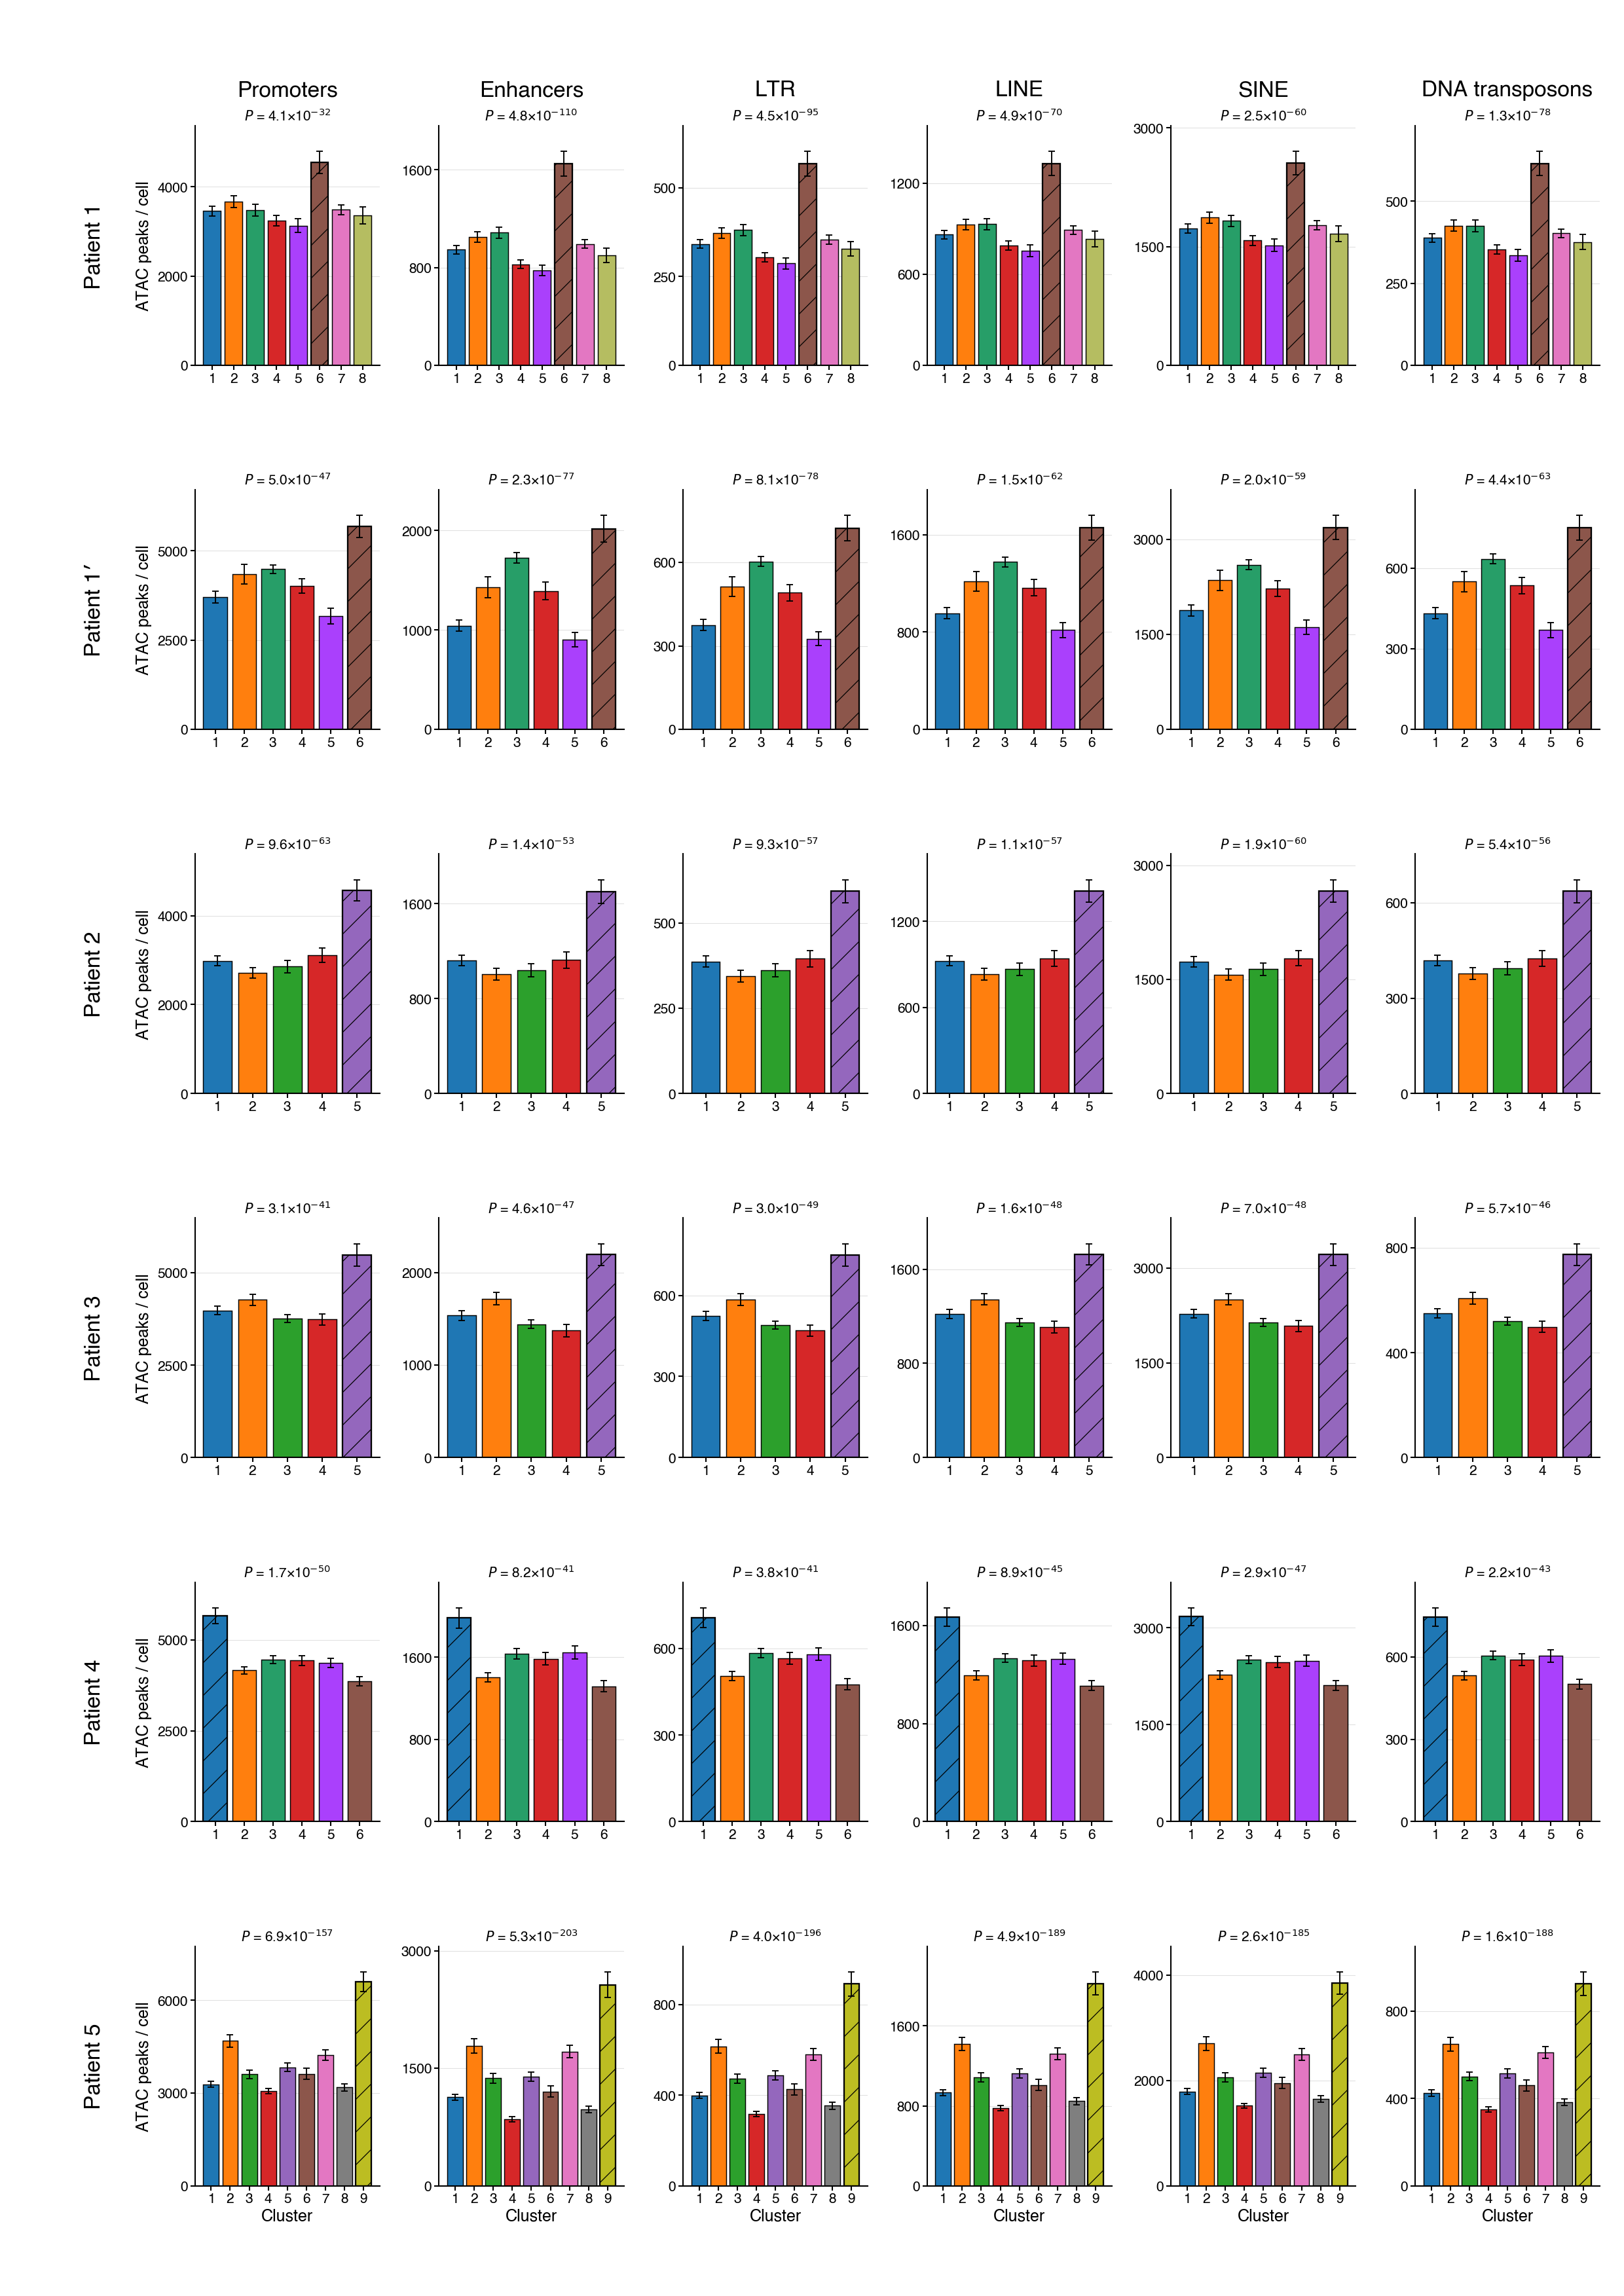

In [4]:
from pathlib import Path

from IPython.display import Image, display

# cell 2 switches matplotlib to Agg, so display the saved PNG directly
display(Image(filename=str(Path.cwd() / "peak_classes_A4.png")))
